# Exercise 2 — Classification Metrics

## Part A: Understanding Model Evaluation

In classification problems, accuracy alone is not always enough.

A model may appear “good” while still making important mistakes.

In this exercise, we will learn how to evaluate classification models using:

* accuracy
* precision
* recall
* F1-score
* confusion matrix

### Example Problem

Imagine we are building a spam detector.

The model predicts:

`1 = spam`

`0 = not spam`

### Step 1 — Real Labels vs Predictions

In [1]:
import numpy as np

# True labels
y_true = np.array([
    1,1,1,1,1,
    0,0,0,0,0
])

# Model predictions
y_pred = np.array([
    1,1,1,0,1,
    0,0,1,0,0
])

### Step 2 — Compute the Confusion Matrix

In [2]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[4 1]
 [1 4]]


### Understanding the Confusion Matrix

Where:

* TP = true positives
* TN = true negatives
* FP = false positives
* FN = false negatives

### Visualize the Confusion Matrix

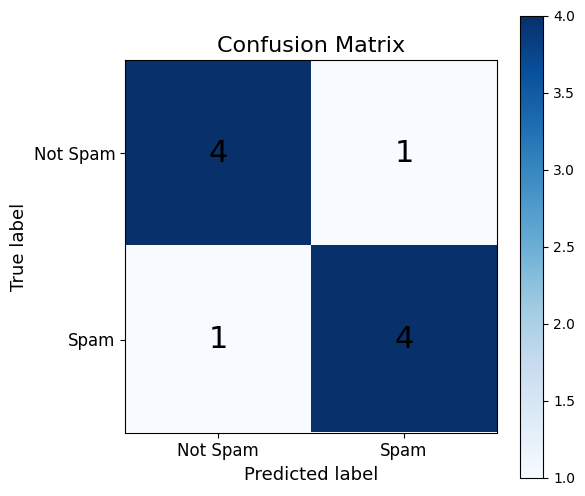

In [3]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(6,6))

plt.imshow(cm, cmap="Blues")

# Axis labels
classes = ["Not Spam", "Spam"]

plt.xticks([0,1], classes, fontsize=12)
plt.yticks([0,1], classes, fontsize=12)

# Numbers inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=22,
            color="black"
        )

# Labels
plt.xlabel("Predicted label", fontsize=13)
plt.ylabel("True label", fontsize=13)

plt.title("Confusion Matrix", fontsize=16)

plt.colorbar()

plt.show()

### Step 3 — Compute Metrics

In [4]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy : {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall   : {recall:.2f}")
print(f"F1-score : {f1:.2f}")

Accuracy : 0.80
Precision: 0.80
Recall   : 0.80
F1-score : 0.80


### What Do These Metrics Mean?

#### Accuracy
How many predictions were correct overall?

Precision
When the model predicts SPAM,
how often is it correct?

Recall
How many real spam messages
did the model find?

F1-score
Balance between precision and recall


8 out of 10 predictions were correct overall.
It is correct 80%
TP/(TP+FP)=4/5=80%
Precision and Recall is both 0.8, so F1-score is also 0.8.

Questions

1. Is accuracy always enough?
2. What happens if classes are imbalanced?
3. Why might high accuracy still be misleading?
4. In medical diagnosis, which is worse:
    * false positive?
    * false negative?
5. Which metric would matter most for:
    * spam filtering?
    * fraud detection?
    * disease detection?

1. No, accurary shows total percentage of correct predictions, but not distinguish the error types that model makes.
2. A model can achieve 99% accuracy, while fail to detect minority class.
3. Because the tiny part of inaccuracy might be crucial errors associated with important factors.
4. False Negative is worse because disease would be missed out and hence dangerous.
5. Spam filtering: Precision, so important emails do not go to junk folder
    Fraud detection: Recall, to catch as many fraud as possible
    Disease detection: Recall, to not miss any ill person

## Part B — Try Your Own Predictions

Modify: `y_pred`

Then rerun the notebook and observe:

* how the confusion matrix changes
* how the metrics change
* which mistakes increase or decrease

In [3]:
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

y_true = np.array([1, 1, 1, 1, 1, 0, 0, 0, 0, 0])

# new cautious model
y_pred = np.array([1, 0, 0, 0, 1, 0, 0, 0, 0, 0])

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)
print(f"Accuracy : {accuracy_score(y_true, y_pred):.2f}")
print(f"Precision: {precision_score(y_true, y_pred):.2f}")
print(f"Recall   : {recall_score(y_true, y_pred):.2f}")
print(f"F1-score : {f1_score(y_true, y_pred):.2f}")

Confusion Matrix:
 [[5 0]
 [3 2]]
Accuracy : 0.70
Precision: 1.00
Recall   : 0.40
F1-score : 0.57


- All element of confusion matrix has changed.
- Precision increased from 0.80 to 1.00
- Recall decreased from 0.80 to 0.40
- F1-Score decreased from 0.80 to 0.57
- False Positive Decreased and False Negative increased.

## Bonus Challenge

Create:

1. a model with:
    * high precision
    * low recall
2. a model with:
    * high recall
    * low precision

Explain the difference.

In [4]:
import numpy as np
from sklearn.metrics import precision_score, recall_score

y_true = np.array([1, 1, 1, 1, 1, 0, 0, 0, 0, 0])

# High Precision, Low Recall
y_pred_high_p = np.array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# High Recall, Low Precision 
y_pred_high_r = np.array([1, 1, 1, 1, 1, 1, 1, 0, 1, 1])

print(f"Skeptic Model -> Precision: {precision_score(y_true, y_pred_high_p):.2f}, Recall: {recall_score(y_true, y_pred_high_p):.2f}")
print(f"Alarmist Model -> Precision: {precision_score(y_true, y_pred_high_r):.2f}, Recall: {recall_score(y_true, y_pred_high_r):.2f}")

Skeptic Model -> Precision: 1.00, Recall: 0.20
Alarmist Model -> Precision: 0.56, Recall: 1.00


The high precision is reliable when it make predictions, but usually silent when it supposed to make an alert. Useful when the False Alarm has high importance.
The high recall is effective against detecting threats, but can easily make false alarms. Useful when we cannot afford to miss a case.